In [34]:
# Determiner Acceptance Efficacite : Ngen / Nrec

# acceptance : geometrique, muon qui partent dans la direction du detecteur
# pas facile a decorreler car difficile a differencier
# probabilite de detection

# tom et mathieu en tienne pas compte des trou dans le detecteur, on leur donne le vrai nombre de J/Psi
# derive de deux facon
# general : 
# et en fonction de la rapidite (invariant de lorentz) (positive dans ALICE, pas la pseudo-rapidite en revenche) : on doit utiliser plusieurs tranche de rapidite (voir avec mathieu et tom les tranches qu'il ont choisi)

#1 - spectre en masse invariante (revoir planif a la fin)
#2 - n reconstruit, n genere
#    rapport en fonction de la rapidite (tranche facilement modifiable)
#3 - correction faite dans les memes conditions : ex : reconstruction impulsion on coupe sur pseudo rap pour etre sur que muon dans detecteur; 
#4 - spectre en masse invariant du J/Psi reconstruit
#5 - incertitiude lie a nos choix

# erreur systematique a estimer
# erreur statistique negligeable (par rapport aux autres)

In [35]:
import uproot
import awkward as ak
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import math
import hist
import vector
print("uproot version",uproot.__version__)
print("awkward version",ak.__version__)
print("numpy version",np.__version__)
print("matplotlib version",matplotlib.__version__)
print("hist version",hist.__version__)
print("vector version",vector.__version__)
from scipy.optimize import curve_fit
from scipy.special import erf 

vector.register_awkward() 

uproot version 5.5.1
awkward version 2.7.2
numpy version 2.1.3
matplotlib version 3.9.0
hist version 2.8.0
vector version 1.5.2


In [36]:
# nMuonsGen : Nombre total de trace candidats muons générés dans l’événement 
# nMuons : Nombre total de trace candidats muons dans l’événement 


file = uproot.open("/pbs/throng/training/nantes-m2-rps-exp/data/run291263.mc.root")  # runXXX.mc.root pour les donnees simulees

gen = file["genTree"]
gen.show()

m = gen.arrays(["nMuonsGen","Muon_GenPx","Muon_GenPy","Muon_GenPz","Muon_GenE","Muon_GenLabel","Muon_GenMotherPDGCode"]) 
m[1].show()

nMuonsGen = 0
for i in range(len(m)):
    info = m[i]["nMuonsGen"]
    nMuonsGen += info
print("nMuonsGen = ", nMuonsGen)

events = file["eventsTree"]

n = events.arrays(["zVtx","isCMUL","nMuons","Muon_Px","Muon_Py","Muon_Pz","Muon_E","Muon_Charge","Muon_thetaAbs","Muon_matchedTrgThreshold","Muon_MCLabel"]) #10000 pour essayer a modifier apres

nMuons = 0
for i in range(len(n)):
    info = n[i]["nMuons"]
    nMuons += info
print("nMuons = ", nMuons)

name                 | typename                 | interpretation                
---------------------+--------------------------+-------------------------------
xVtxMC               | double                   | AsDtype('>f8')
yVtxMC               | double                   | AsDtype('>f8')
zVtxMC               | double                   | AsDtype('>f8')
nMuonsGen            | int32_t                  | AsDtype('>i4')
Muon_GenE            | std::vector<float>       | AsJagged(AsDtype('>f4'), he...
Muon_GenPx           | std::vector<float>       | AsJagged(AsDtype('>f4'), he...
Muon_GenPy           | std::vector<float>       | AsJagged(AsDtype('>f4'), he...
Muon_GenPz           | std::vector<float>       | AsJagged(AsDtype('>f4'), he...
Muon_GenLabel        | std::vector<int32_t>     | AsJagged(AsDtype('>i4'), he...
Muon_GenMotherPDG... | std::vector<int32_t>     | AsJagged(AsDtype('>i4'), he...
{nMuonsGen: 2,
 Muon_GenPx: [0.869, -0.973],
 Muon_GenPy: [-1.54, 1.33],
 Muon_GenPz: [-26.1

In [37]:
#calcul de masse invariante de spectre 

def getTracks(events):
    return ak.zip({"px":events["Muon_Px"],
                       "py":events["Muon_Py"],
                       "pz":events["Muon_Pz"],
                       "E":events["Muon_E"],
                       "charge":events["Muon_Charge"],
                       "thetaAbs":events["Muon_thetaAbs"],
                       "matched":events["Muon_matchedTrgThreshold"]},
                    with_name='Momentum4D')

tracks = getTracks(n)
print(tracks)
print(type(tracks))
a = tracks[1][0]
b = tracks[1][1]
(a+b).M

#a.M() # ou a.mass() pour determine la masse invariante de l'object akward

[[{px: 2.02, py: -0.932, pz: -30.1, E: 30.2, charge: 1, ...}, {...}], ...]
<class 'vector.backends.awkward.MomentumArray4D'>


np.float32(3.4796598)

150000
43505


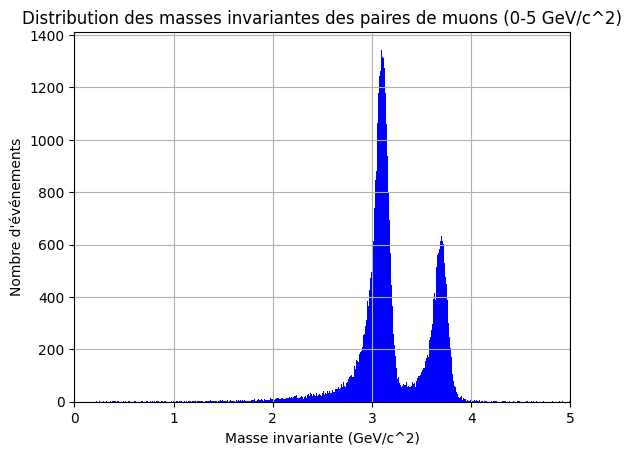

In [38]:
print(len(n.nMuons))
# Filtrer les événements avec nMuons == 2 et isCMUL == True
filtered_events = n[(n.nMuons > 1)] #& (n.isCMUL)&(abs(n.zVtx)<10)]

print(len(filtered_events))

# Initialiser les vecteurs à partir des données des muons
muon_vectors = ak.zip({
    "px": filtered_events.Muon_Px,
    "py": filtered_events.Muon_Py,
    "pz": filtered_events.Muon_Pz,
    "E": filtered_events.Muon_E
}, with_name="Momentum4D")

# Calculer les masses invariantes pour chaque paire de muons dans chaque événement
invariant_masses = ak.combinations(muon_vectors, 2, fields=["muon1", "muon2"])
masses = (invariant_masses.muon1 + invariant_masses.muon2).mass

# Créer un histogramme des valeurs de la masse
flattened_masses = ak.flatten(masses)  # Aplatir les données pour l'histogramme
filtered_masses = flattened_masses[(flattened_masses >= 0) & (flattened_masses <= 5)]  # Filtrer les masses entre 0 et 10
plt.hist(filtered_masses, bins=500, color='blue')
plt.xlabel('Masse invariante (GeV/c^2)')
plt.ylabel("Nombre d'événements")
plt.xlim(0,5)
plt.title('Distribution des masses invariantes des paires de muons (0-5 GeV/c^2)')
plt.grid(True)
plt.show()

In [39]:
#print(len(n.nMuons))
#150000
#print(n.Muon_MCLabel)
#[[1, 2], [2, 1], [1], [2, 1], [2], [], ..., [], [1], [1, 2], [2, 1], [1], [2]]
#print(m.Muon_GenLabel)
#[[1, 2], [1, 2], [1, 2], [1, 2], [1, ...], ..., [1, 2], [1, 2], [1, 2], [1, 2]]
#print(len(n.Muon_MCLabel))
#150000
#print(len(m.Muon_GenLabel))
#150000
#print(m.Muon_GenMotherPDGCode)
#[[100443, 100443], [100443, 100443], [...], ..., [100443, 100443], [443, 443]]

print(len(n))
print(f"filtre : ", m[ak.all(m["Muon_GenMotherPDGCode"] == 443, axis=1)])
print(f"longueur :",len(m[ak.all(m["Muon_GenMotherPDGCode"] == 443, axis=1)]))


mask = (n["nMuons"] >= 2) & ak.all(m["Muon_GenMotherPDGCode"] == 443, axis=1) 
inverse_mask = ~((n["nMuons"] >= 2) & ak.all(m["Muon_GenMotherPDGCode"] == 443, axis=1))

print(f"filtre=", n[mask])
print(f"longueur :",len(n[mask]))
print(f"filtre=", n[inverse_mask])
print(f"longueur :",len(n[inverse_mask]))
print(len(n[mask])+len(n[inverse_mask]))

150000
filtre :  [{nMuonsGen: 2, Muon_GenPx: [1.8, 2.65], Muon_GenPy: [...], ...}, ..., {...}]
longueur : 100140
filtre= [{zVtx: -2.88, isCMUL: True, nMuons: 2, Muon_Px: [...], Muon_Py: ..., ...}, ...]
longueur : 29228
filtre= [{zVtx: -4.78, isCMUL: True, nMuons: 2, Muon_Px: [...], Muon_Py: ..., ...}, ...]
longueur : 120772
150000


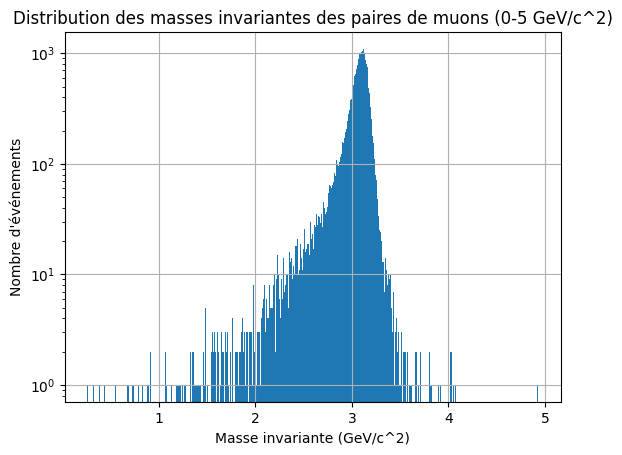

22801
22801


In [40]:
# Filtrer les événements avec nMuons == 2 et isCMUL == True
filtered_events = n[mask & (n.isCMUL)&(abs(n.zVtx)<10)]

muon_vectors = ak.zip({
    "px": filtered_events.Muon_Px,
    "py": filtered_events.Muon_Py,
    "pz": filtered_events.Muon_Pz,
    "E": filtered_events.Muon_E
}, with_name="Momentum4D")

# Calculer les masses invariantes pour chaque paire de muons dans chaque événement
invariant_masses = ak.combinations(muon_vectors, 2, fields=["muon1", "muon2"])
masses = (invariant_masses.muon1 + invariant_masses.muon2).mass

# Créer un histogramme des valeurs de la masse
flattened_masses = ak.flatten(masses)  # Aplatir les données pour l'histogramme
filtered_masses = flattened_masses[(flattened_masses >= 0) & (flattened_masses <= 5)]  # Filtrer les masses entre 0 et 10


hist, bin_edges = np.histogram(flattened_masses, bins=500, range=(0, 5))
plt.hist(filtered_masses, bins=500)
    
plt.xlabel('Masse invariante (GeV/c^2)')
plt.ylabel("Nombre d'événements")
#plt.xlim(0,5)
#plt.ylim(0,1200)
plt.yscale('log')
plt.title('Distribution des masses invariantes des paires de muons (0-5 GeV/c^2)')
plt.grid(True)
plt.show()

print(len(masses)) #nb j/psi
print(len(filtered_events)) 

In [25]:
#Fit CB2
def CB2 (x, N, mu, sig, alphaL, nL, alphaR, nR):
    #nL correspond a n 
    #nR correspond a n'
    #alphaL correspond a a 
    #alphaR correspond a a'
    AL = ( nL / np.absolute( alphaL ) )**nL * np.exp( -1 * np.absolute( alphaL )**2 / 2 )
    AR = ( nR / np.absolute( alphaR ) )**nR * np.exp( -1 * np.absolute( alphaR )**2 / 2 )
    BL = nL / np.absolute( alphaL ) - np.absolute( alphaL )
    BR = nR / np.absolute( alphaR ) - np.absolute( alphaR )
    
    return np.piecewise(x, 
                        [( x - mu )/sig <= 1 * alphaL, 
                         (( x - mu )/sig > 1 * alphaL) & (( x - mu )/sig < alphaR)
                         , ( x - mu )/sig >= alphaR],
                        [lambda x: N * AL * (BL - (( x - mu )/sig))**(-nL), 
                         lambda x: N * np.exp(-0.5 * (( x - mu )/sig)**2), 
                         lambda x: N * AR * (BR + ( x - mu )/sig)**(-nR)])

def crystal_ball(x, N, mu, sigma, alpha, n):
    t = (x - mu) / sigma
    A = (n / abs(alpha))**n * np.exp(-alpha**2 / 2)
    B = n / abs(alpha) - abs(alpha)
    C = (n / abs(alpha)) / (n - 1) * np.exp(-alpha**2 / 2)
    D = np.sqrt(np.pi / 2) * (1 + erf(abs(alpha) / np.sqrt(2)))
    norm = sigma * (C + D)
    result = np.piecewise(
        t,
        [t > -alpha, t <= -alpha],
        [lambda t: N * np.exp(-t**2 / 2) / norm,
         lambda t: N * A * (B - t)**(-n) / norm]
    )
    return result

def na60(x, N, mu, sigma, alphaL, alphaR, pL, pR):
    t = (x - mu) / sigma
    t_s = np.piecewise(
        t,
        [t < -alphaL, (t >= -alphaL) & (t <= alphaR), t > alphaR],
        [lambda t: 1 + pL * (-alphaL - t)**3,
         lambda t: 1,
         lambda t: 1 + pR * (t - alphaR)**3]
    )
    return N * np.exp(-0.5 * (t**2) * t_s)


Paramètres CB2 : [2.19013841e+02 3.10255953e+00 6.14104163e-02 7.67196262e-01
 5.82065712e+00]
Paramètres NA60 : [ 1.05041356e+03  3.10129780e+00  8.25852362e-02  1.00000000e-01
  1.00000000e-01 -7.57951378e-03  4.51853173e-01]


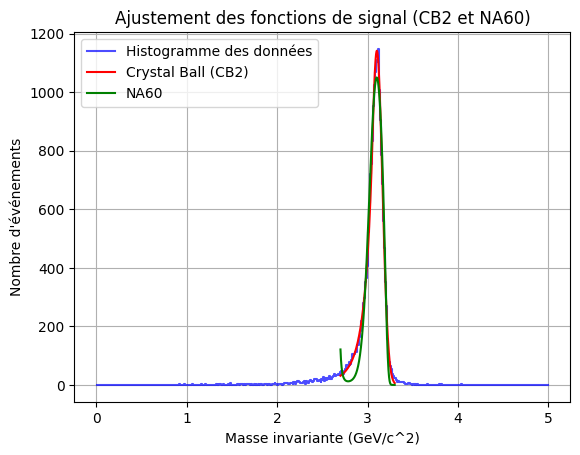

In [28]:
bin_centers = np.asarray((bin_edges[:-1] + bin_edges[1:]) / 2)
y_data = np.asarray(hist)
valid_indices = (bin_centers >= 2.7) & (bin_centers <= 3.3)
x_peak = bin_centers[valid_indices]
y_peak = y_data[valid_indices]


try:
    popt_cb2, pcov_cb2 = curve_fit(
        crystal_ball, x_peak, y_peak,
        p0=[np.max(y_peak), 3.0, 0.1, 1.5, 5],
        bounds=([0, 2.7, 0.01, 0.1, 1], [np.inf, 3.3, 1, 5, 10]),
        maxfev=200000
    )
except RuntimeError as e:
    print("Erreur d'ajustement Crystal Ball :", e)

try:
    popt_na60, pcov_na60 = curve_fit(
        na60, x_peak, y_peak,
        p0=[np.max(y_peak), 3.0, 0.1, 1.5, 1.5, 0.1, 0.1],
        bounds=([0, 2.7, 0.01, 0.1, 0.1, -1, -1], [np.inf, 3.3, 1, 5, 5, 1, 1]),
        maxfev=200000
    )
except RuntimeError as e:
    print("Erreur d'ajustement NA60 :", e)

# Générer les courbes ajustées
x_fit = np.linspace(2.7, 3.3, 1000)
y_cb2 = crystal_ball(x_fit, *popt_cb2) if 'popt_cb2' in locals() else None
y_na60 = na60(x_fit, *popt_na60) if 'popt_na60' in locals() else None

# Résultats de l'ajustement
if 'popt_cb2' in locals():
    print(f"Paramètres CB2 : {popt_cb2}")
if 'popt_na60' in locals():
    print(f"Paramètres NA60 : {popt_na60}")

# Tracer les données et les ajustements
plt.step(bin_centers, y_data, where='mid', label='Histogramme des données', color='blue', alpha=0.7)
if y_cb2 is not None:
    plt.plot(x_fit, y_cb2, label='Crystal Ball (CB2)', color='red')
if y_na60 is not None:
    plt.plot(x_fit, y_na60, label='NA60', color='green')

# Mise en forme
plt.xlabel('Masse invariante (GeV/c^2)')
plt.ylabel('Nombre d\'événements')
plt.title('Ajustement des fonctions de signal (CB2 et NA60)')
plt.legend()
plt.grid(True)
plt.show()

In [29]:
from scipy.integrate import quad

# Intégration de la fonction Crystal Ball
if y_cb2 is not None:
    area_cb2, _ = quad(lambda x: crystal_ball(x, *popt_cb2), 2.7, 3.3)
    print(f"Nombre de J/psi estimé (CB2) : {area_cb2}")

# Intégration de la fonction NA60
if y_na60 is not None:
    area_na60, _ = quad(lambda x: na60(x, *popt_na60), 2.7, 3.3)
    print(f"Nombre de J/psi estimé (NA60) : {area_na60}")


Nombre de J/psi estimé (CB2) : 213.55452085902218
Nombre de J/psi estimé (NA60) : 200.06707889869818


150000
97347


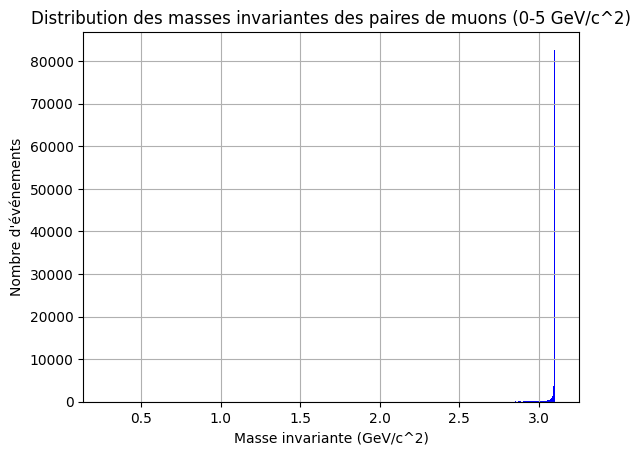

In [43]:
m = gen.arrays(["nMuonsGen","Muon_GenPx","Muon_GenPy","Muon_GenPz","Muon_GenE","Muon_GenMotherPDGCode"]) 

print(len(m.nMuonsGen))
# Filtrer les événements avec nMuons == 2 et isCMUL == True
filtered_events = m[ak.all(m["Muon_GenMotherPDGCode"] == 443, axis=1) &(abs(n.zVtx)<10)]

print(len(filtered_events))

# Initialiser les vecteurs à partir des données des muons
muon_vectors = ak.zip({
    "px": filtered_events.Muon_GenPx,
    "py": filtered_events.Muon_GenPy,
    "pz": filtered_events.Muon_GenPz,
    "E": filtered_events.Muon_GenE
}, with_name="Momentum4D")

# Calculer les masses invariantes pour chaque paire de muons dans chaque événement
invariant_masses = ak.combinations(muon_vectors, 2, fields=["muon1", "muon2"])
masses = (invariant_masses.muon1 + invariant_masses.muon2).mass

# Créer un histogramme des valeurs de la masse
flattened_masses = ak.flatten(masses)  # Aplatir les données pour l'histogramme
filtered_masses = flattened_masses[(flattened_masses >= 0) & (flattened_masses <= 5)]  # Filtrer les masses entre 0 et 10
plt.hist(filtered_masses, bins=500, color='blue')
plt.xlabel('Masse invariante (GeV/c^2)')
plt.ylabel("Nombre d'événements")
#plt.xlim(0,5)
plt.title('Distribution des masses invariantes des paires de muons (0-5 GeV/c^2)')
plt.grid(True)
plt.show()

In [ ]:
#acceptance efficacite en fonction de la distribution pt

In [ ]:
# Filtrer les événements avec nMuons == 2 et isCMUL == True
filtre = [n[(n.nMuons > 1) & (n.isCMUL)&(abs(n.zVtx)<10)], n[mask & (n.isCMUL)&(abs(n.zVtx)<10)]] #& (n.isCMUL)&(abs(n.zVtx)<10)]
filtered_events = 0

for i in filtre :
    filtered_events=i
# Initialiser les vecteurs à partir des données des muons
    muon_vectors = ak.zip({
        "px": filtered_events.Muon_Px,
        "py": filtered_events.Muon_Py,
        "pz": filtered_events.Muon_Pz,
        "E": filtered_events.Muon_E
    }, with_name="Momentum4D")

    # Calculer les masses invariantes pour chaque paire de muons dans chaque événement
    invariant_masses = ak.combinations(muon_vectors, 2, fields=["muon1", "muon2"])
    masses = (invariant_masses.muon1 + invariant_masses.muon2).mass

    # Créer un histogramme des valeurs de la masse
    flattened_masses = ak.flatten(masses)  # Aplatir les données pour l'histogramme
    filtered_masses = flattened_masses[(flattened_masses >= 0) & (flattened_masses <= 5)]  # Filtrer les masses entre 0 et 10
    plt.hist(filtered_masses, bins=500)
    
plt.xlabel('Masse invariante (GeV/c^2)')
plt.ylabel("Nombre d'événements")
#plt.xlim(0,5)
#plt.ylim(0,1200)
plt.yscale('log')
plt.title('Distribution des masses invariantes des paires de muons (0-5 GeV/c^2)')
plt.grid(True)
plt.show()
